In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.helpers import make_aesthetic, cat_stats

raw = pd.read_csv("../data/qualtrics_experiments/[ssl] ssl_survey_October 13, 2025_11.24.csv").iloc[2:]
print(raw.columns)

demos = pd.read_csv("../data/qualtrics_experiments/prolific_export_68ed14366f5dc62f56b3fb13.csv")



# Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
#        'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
#        'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
#        'ExternalReference', 'LocationLatitude', 'LocationLongitude',
#        'DistributionChannel', 'UserLanguage', 'commit', 'pid', 'attn1',
#        'dv_llm_usage', 'dv_use_moral', 'dv_use_moral_feed',
#        'dv_use_moral_desc', 'dv_use_personal', 'dv_use_personal_feed',
#        'dv_use_personal_desc', 'dv_use_con', 'dv_use_con_feed',
#        'dv_use_con_desc', 'race', 'educ', 'income', 'gender', 'gender_4_TEXT',
#        'age'],

data = []
for idx, row in raw.iterrows():
    data_pt = {}
    data_pt["pid"] = row["pid"]
    data_pt["duration"] = row["Duration (in seconds)"]
    data_pt["any_llm"] = row['dv_llm_usage']
    data_pt["moral"] = row['dv_use_moral']
    data_pt["moral_feed"] = row['dv_use_moral_feed']
    data_pt["moral_desc"] = row['dv_use_moral_desc']
    data_pt["personal"] = row['dv_use_personal']
    data_pt["personal_feed"] = row['dv_use_personal_feed']
    data_pt["personal_desc"] = row['dv_use_personal_desc']
    data_pt["con"] = row['dv_use_con']
    data_pt["con_feed"] = row['dv_use_con_feed']
    data_pt["con_desc"] = row['dv_use_con_desc']
    data_pt['commit'] = row['commit']
    data_pt['attn1'] = row['attn1']
    data.append(data_pt)

df = pd.DataFrame(data)


# CLEANING
###########################

# Option mapping
LLM_USAGE_MAP = {
    "Yes - almost constantly": 5,
    "Yes - several times a day": 4,
    "Yes - about once a day": 3,
    "Yes - several times a week": 2,
    "Yes - less often than several times a week": 1,
    "No - never used": 0
}


import pandas as pd
import numpy as np

def make_representative_weights(df: pd.DataFrame, col: str, ground_truth: dict) -> pd.DataFrame:
    """
    Compute nationally representative weights for a categorical variable.

    Args:
        df (pd.DataFrame): Input dataframe.
        col (str): Column name representing the categorical variable (e.g., 'any_llm').
        ground_truth (dict): Dictionary mapping category → population frequency proxy.
            - Values can represent prevalence, period, or inverse likelihood (e.g., weeks between usage).
            - Higher values = less frequent in population.

    Returns:
        pd.DataFrame: Original dataframe with an added 'weight' column.

    Example:
        df = make_representative_weights(df, 'any_llm', LLM_USAGE_GT)
    """
    # Compute population proportions
    pop_gt = pd.Series(ground_truth)
    pop_prop = 1 / pop_gt  # inverse if larger = rarer (as in GT weeks)
    pop_prop = pop_prop / pop_prop.sum()

    # Compute sample proportions
    sample_prop = df[col].value_counts(normalize=True)

    # Merge into a single weight table
    weight_table = pd.DataFrame({
        'pop_prop': pop_prop,
        'sample_prop': sample_prop
    }).fillna(0)

    # Compute weights
    weight_table['weight'] = weight_table['pop_prop'] / weight_table['sample_prop']
    weight_table['weight'] = weight_table['weight'].replace([np.inf, -np.inf], np.nan)

    # Merge weights back into dataframe
    df = df.copy()
    df['weight'] = df[col].map(weight_table['weight'])

    # Normalize weights so mean = 1 (optional)
    df['weight'] = df['weight'] / df['weight'].mean()

    return df


LLM_USAGE_GT = {
    "Yes - almost constantly": 5,
    "Yes - several times a day": 7,
    "Yes - about once a day": 5,
    "Yes - several times a week": 10,
    "Yes - less often than several times a week": 25,
    "No - never used": 52
}


df['duration'] = pd.to_numeric(df['duration'], errors='coerce')/60
for var in ['any_llm', 'moral', 'personal', 'con']:
    name = var + '_num'
    df[name] = df[var].map(LLM_USAGE_MAP)
    any_name = 'any_' + var
    df[any_name] = df[name].apply(lambda x: 1 if x > 0 else 0)


df['any_usage'] = df[['any_moral', 'any_personal', 'any_con']].max(axis=1)
dvs = ['moral', 'personal', 'con']
df = make_representative_weights(df, 'any_llm', LLM_USAGE_GT)

# FILTERING ATTN CHECK
###########################
df = df[df['attn1'] == '25']
df = df[df['commit'] == 'Yes, I will']


# FILTERING LLM USERS
###########################
print("Filtering out non-llm users")
print(f"Original N: {len(df)}")
df = df[df['any_llm'] != 'No - never used']
print(f"N after filtering: {len(df)}")
print()

df = pd.merge(df, demos, left_on='pid', right_on=['Participant id'], how='left')


Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName', 'RecipientFirstName', 'RecipientEmail',
       'ExternalReference', 'LocationLatitude', 'LocationLongitude',
       'DistributionChannel', 'UserLanguage', 'commit', 'pid', 'attn1',
       'dv_llm_usage', 'dv_use_moral', 'dv_use_moral_feed',
       'dv_use_moral_desc', 'dv_use_personal', 'dv_use_personal_feed',
       'dv_use_personal_desc', 'dv_use_con', 'dv_use_con_feed',
       'dv_use_con_desc', 'race', 'educ', 'income', 'gender', 'gender_4_TEXT',
       'age'],
      dtype='object')
Filtering out non-llm users
Original N: 49
N after filtering: 46



In [11]:
df['any_llm'].value_counts(normalize=True)

any_llm
Yes - several times a day                     0.369565
Yes - several times a week                    0.304348
Yes - less often than several times a week    0.217391
Yes - about once a day                        0.108696
Name: proportion, dtype: float64

In [2]:
import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def weighted_proportions(df: pd.DataFrame, factor_col: str, weight_col: str, return_ci: bool = False) -> pd.Series:
    """
    Compute weighted proportions for a categorical variable.

    Args:
        df (pd.DataFrame): Input DataFrame.
        factor_col (str): Column name of the categorical variable.
        weight_col (str): Column name of the weight variable.
        return_ci (bool): Whether to return confidence intervals using analytical formula. Default False.

    Returns:
        pd.Series or pd.DataFrame: Weighted proportions of each category (summing to 1).
                                   If return_ci=True, returns DataFrame with proportion, se, ci_lower, ci_upper.

    Example:
        >>> weighted_proportions(df, 'any_llm', 'weight')
        >>> weighted_proportions(df, 'any_llm', 'weight', return_ci=True)

    Note:
        I am getting the weighted SE from here (https://stats.stackexchange.com/questions/159204/how-to-calculate-the-standard-error-of-a-proportion-using-weighted-data),
        and then multiplying by 1.96 for the 95% CI.
    """
    # Drop rows with missing values
    data = df[[factor_col, weight_col]].dropna()

    # Standardize weights to sum to 1 (unity)
    weight_sum_total = data[weight_col].sum()
    data = data.copy()
    data['standardized_weight'] = data[weight_col] / weight_sum_total

    # Sum standardized weights by category to get proportions
    proportions = data.groupby(factor_col)['standardized_weight'].sum()

    if return_ci:
        # Use the analytical formula for standard errors
        results = []

        # Sum of squared standardized weights (computed once)
        sum_w_squared = (data['standardized_weight'] ** 2).sum()

        print(f"Sum of squared standardized weights: {sum_w_squared}")
        print("1 over n", 1/len(data))

        for category in proportions.index:
            # Weighted proportion
            p_hat = proportions[category]

            # Standard error using formula: SE = sqrt(p_hat * (1 - p_hat) * sum(w_i^2))
            se = np.sqrt(p_hat * (1 - p_hat) * sum_w_squared)

            # 95% confidence interval
            ci_lower = max(0, p_hat - 1.96 * se)
            ci_upper = min(1, p_hat + 1.96 * se)

            results.append({
                'category': category,
                'proportion': p_hat,
                'se': se,
                'ci_lower': ci_lower,
                'ci_upper': ci_upper
            })

        proportions = pd.DataFrame(results).set_index('category')

    return proportions

n_dupes = int(800/50)
df['dummy_weight'] = 1
dfb = pd.concat([df]*n_dupes, ignore_index=True)

results = []

for (weight_var, weight_type) in [('weight', 'weighted'), ('dummy_weight', 'unweighted')]:
    for (dv, name) in zip(["moral", "personal", "con", "usage"], ["Moral", "Personal", "Conventional", "Any SSL"]):
        desc = weighted_proportions(dfb, f'any_{dv}', weight_var, return_ci=True)
        desc = desc.sort_index(ascending=False)

        # Get the 'Yes' row (assuming True/1/Yes is the category you want)
        yes_row = desc.loc[desc.index[0]]  # Takes the first row after sorting descending

        # Add the name and create a row for the results table
        results.append({
            'Weight Type': weight_type,
            'Variable': name,
            'Proportion': round(yes_row['proportion'] * 100, 1),
            'SE': round(yes_row['se'] * 100, 1),
            'CI Lower': round(yes_row['ci_lower'] * 100, 1),
            'CI Upper': round(yes_row['ci_upper'] * 100, 1)
        })
    # add a horizontal line
    results.append({
        'Weight Type': '',
        'Variable': '',
        'Proportion': '',
        'SE': '',
        'CI Lower': '',
        'CI Upper': ''
    })

# Create final DataFrame
results_df = pd.DataFrame(results)
print(results_df)



Sum of squared standardized weights: 0.0027514823529411767
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0027514823529411767
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0027514823529411767
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0027514823529411767
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0013586956521739134
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0013586956521739134
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0013586956521739134
1 over n 0.001358695652173913
Sum of squared standardized weights: 0.0013586956521739134
1 over n 0.001358695652173913
  Weight Type      Variable Proportion   SE CI Lower CI Upper
0    weighted         Moral       24.4  2.3     20.0     28.8
1    weighted      Personal       47.8  2.6     42.7     52.9
2    weighted  Conventional       34.0  2.5     29.1     38.9
3    weighted       Any SSL       67.9  

In [32]:
weighted_proportions(df, 'personal', 'weight', return_ci=True)

Sum of squared standardized weights: 0.04402371764705883
1 over n 0.021739130434782608


,proportion,se,ci_lower,ci_upper
category,,,,
No - never used,0.521976,0.104808,0.316553,0.727400
Yes - about once a day,0.017647,0.027626,0.000000,0.071793
Yes - less often than several times a week,0.407435,0.103096,0.205368,0.609503
Yes - several times a day,0.035294,0.038716,0.000000,0.111178
Yes - several times a week,0.017647,0.027626,0.000000,0.071793


# View desc table

In [24]:
# Create a tidy dataframe with response options
print()
print("Any ssl")
print(df['any_usage'].value_counts(normalize=True).sort_index() * 100)
print()

usage_vars = {
    "moral": "moral_num",
    "conventional": "con_num",
    "personal": "personal_num"
}
rev_map = {v: k for k, v in LLM_USAGE_MAP.items()}
table = pd.DataFrame()
for label, col in usage_vars.items():
    counts = df[col].value_counts(normalize=True).sort_index() * 100
    table[label] = counts
table.index = table.index.map(rev_map)
table = table.fillna(0)
table = table.sort_index(ascending=True)
print(table.round(1))





Any ssl
any_usage
0    41.304348
1    58.695652
Name: proportion, dtype: float64

                                            moral  conventional  personal
moral_num                                                                
No - never used                              76.1          60.9      60.9
Yes - about once a day                        2.2           0.0       2.2
Yes - almost constantly                       2.2           0.0       0.0
Yes - less often than several times a week   17.4          34.8      30.4
Yes - several times a day                     2.2           2.2       4.3


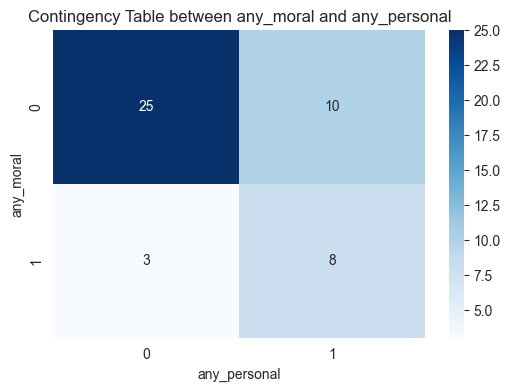

Cramer's V between any_moral and any_personal: 0.3019
Chi2 test between any_moral and any_personal: chi2 = 5.12, p = 0.0236


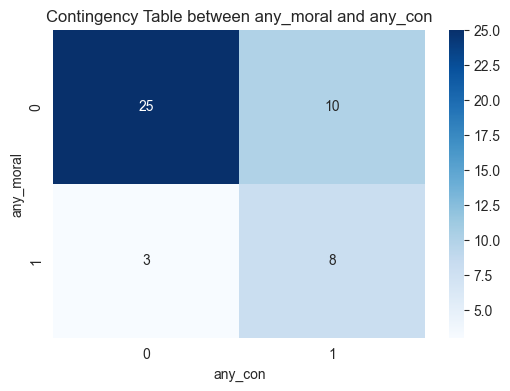

Cramer's V between any_moral and any_con: 0.3019
Chi2 test between any_moral and any_con: chi2 = 5.12, p = 0.0236


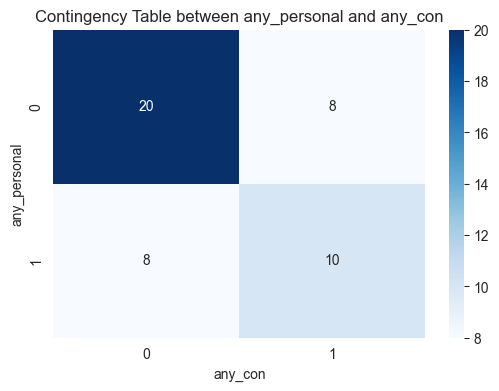

Cramer's V between any_personal and any_con: 0.1694
Chi2 test between any_personal and any_con: chi2 = 2.31, p = 0.1283


In [25]:
def chi2(df, col1, col2):
    from scipy.stats import chi2_contingency
    contingency_table = pd.crosstab(df[col1], df[col2])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Contingency Table between {col1} and {col2}')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()

    # cramer v
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    cramer_v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
    print(f"Cramer's V between {col1} and {col2}: {cramer_v:.4f}")
    return chi2, p

# Pairwise chi2 tests
for i in range(len(dvs)):
    for j in range(i + 1, len(dvs)):
        dv1 = dvs[i]
        dv2 = dvs[j]
        chi2_stat, p_value = chi2(df, f'any_{dv1}', f'any_{dv2}')
        print(f"Chi2 test between any_{dv1} and any_{dv2}: chi2 = {chi2_stat:.2f}, p = {p_value:.4f}")

Categorical variable: age (Age)
Age
41                 4
58                 3
33                 3
51                 3
53                 3
49                 3
43                 2
32                 2
27                 2
56                 2
52                 2
54                 2
37                 1
45                 1
40                 1
28                 1
30                 1
62                 1
20                 1
39                 1
70                 1
55                 1
78                 1
38                 1
CONSENT_REVOKED    1
65                 1
64                 1
Name: count, dtype: int64



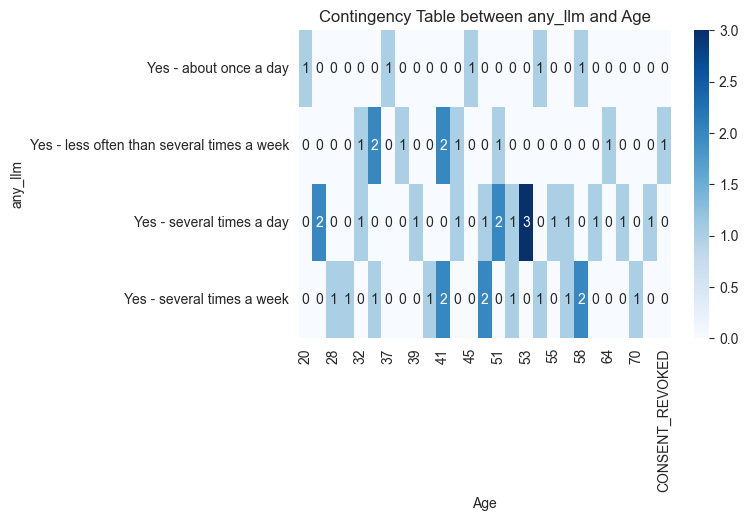

Cramer's V between any_llm and Age: 0.2553
Chi2 test between any_llm and Age: chi2 = 88.13, p = 0.2030


Categorical variable: gender (Sex)
Sex
Male               24
Female             21
CONSENT_REVOKED     1
Name: count, dtype: int64



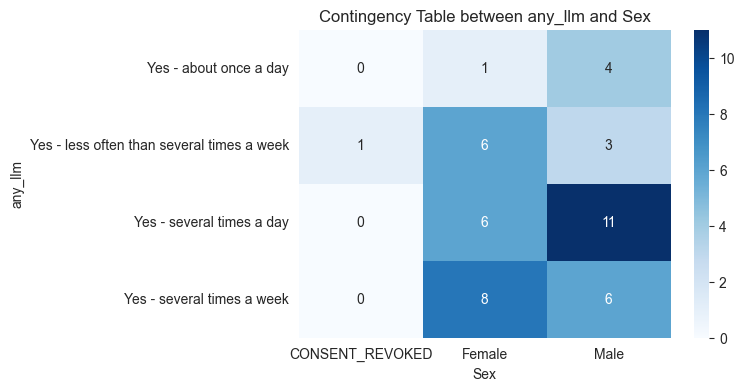

Cramer's V between any_llm and Sex: 0.1459
Chi2 test between any_llm and Sex: chi2 = 8.01, p = 0.2377


Categorical variable: race (Ethnicity simplified)
Ethnicity simplified
White              37
Mixed               5
Asian               2
Black               1
CONSENT_REVOKED     1
Name: count, dtype: int64



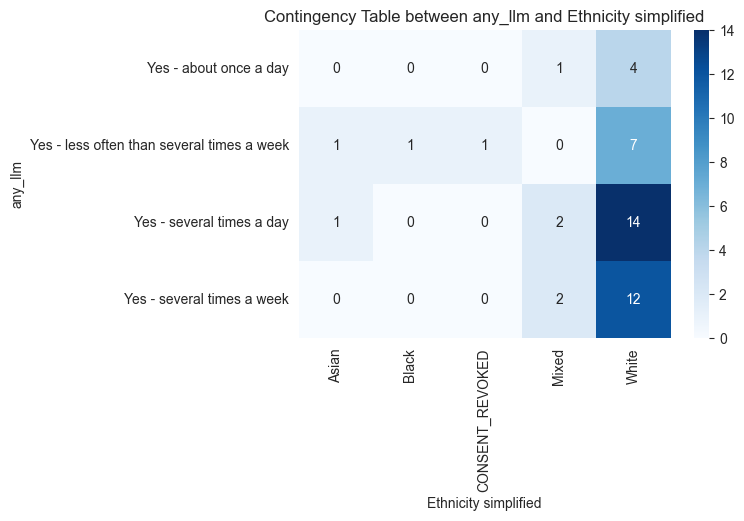

Cramer's V between any_llm and Ethnicity simplified: 0.0000
Chi2 test between any_llm and Ethnicity simplified: chi2 = 10.68, p = 0.5567


Categorical variable: educ (Student status)
Student status
DATA_EXPIRED       22
No                 19
Yes                 4
CONSENT_REVOKED     1
Name: count, dtype: int64



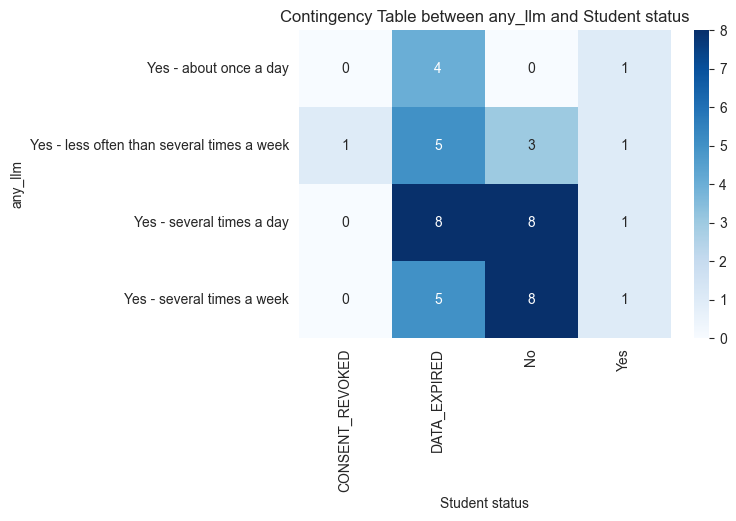

Cramer's V between any_llm and Student status: 0.0425
Chi2 test between any_llm and Student status: chi2 = 9.43, p = 0.3983


Categorical variable: income (Employment status)
Employment status
DATA_EXPIRED                                                21
Full-Time                                                   17
Part-Time                                                    5
Unemployed (and job seeking)                                 1
Not in paid work (e.g. homemaker', 'retired or disabled)     1
CONSENT_REVOKED                                              1
Name: count, dtype: int64



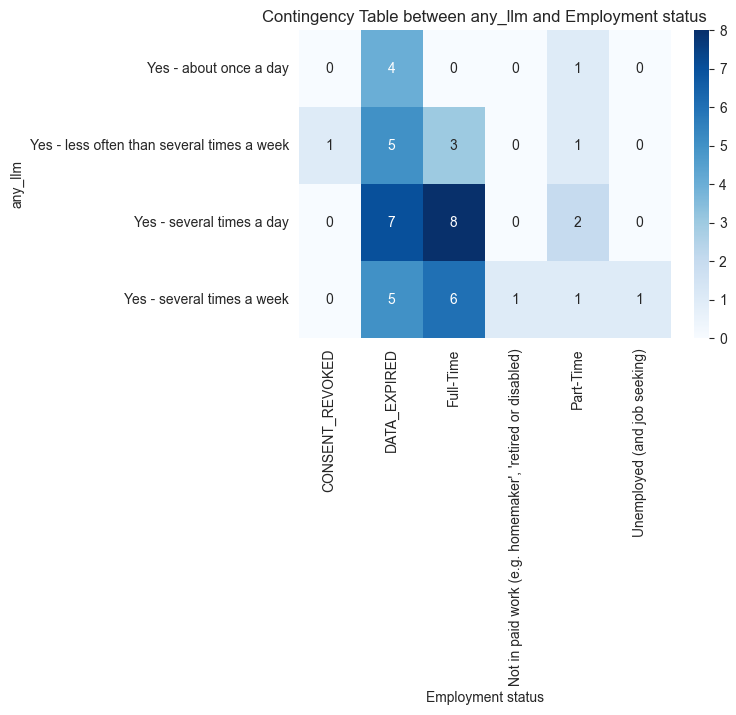

Cramer's V between any_llm and Employment status: 0.0000
Chi2 test between any_llm and Employment status: chi2 = 13.04, p = 0.5989




In [5]:
# Index(['Submission id', 'Participant id', 'Status',
#        'Custom study tncs accepted at', 'Started at', 'Completed at',
#        'Reviewed at', 'Archived at', 'Time taken', 'Completion code',
#        'Total approvals', 'Age', 'Sex', 'Ethnicity simplified',
#        'Country of birth', 'Country of residence', 'Nationality', 'Language',
#        'Student status', 'Employment status'],
#       dtype='object')

# look at if LLM usage differs by these variables

cat_vars = {
    'age': 'Age',
    'gender': 'Sex',
    'race': 'Ethnicity simplified',
    'educ': 'Student status',
    'income': 'Employment status'
}

for var, col in cat_vars.items():
    print(f"Categorical variable: {var} ({col})")
    print(df[col].value_counts())
    print()
    for dv in ['llm']:
        chi2_stat, p_value = chi2(df, f'any_{dv}', col)
        print(f"Chi2 test between any_{dv} and {col}: chi2 = {chi2_stat:.2f}, p = {p_value:.4f}")
    print("\n" + "="*50 + "\n")

<Axes: xlabel='Age', ylabel='any_llm_num'>

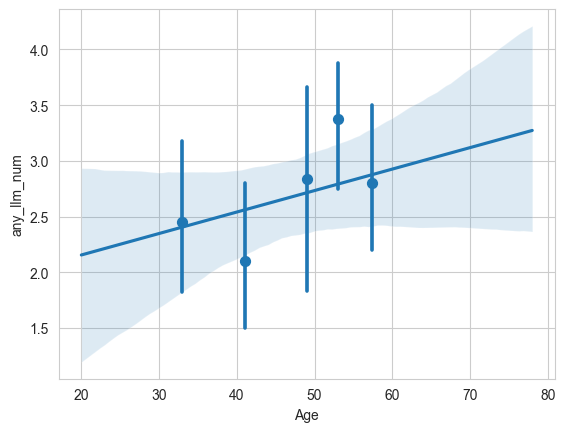

In [28]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
sns.regplot(data=df, x='Age', y='any_llm_num', x_bins=5)